# Notebook 05 — Deep Learning Classifier

**EE7204 / EC7205 — Image Processing and Computer Vision**  
**University of Ruhuna — Department of Electrical and Information Engineering**

---

## Objective

Train a binary classifier that distinguishes **genuine wet-ink stamp impressions**
(Class 0) from **digitally printed forgeries** (Class 1) using transfer learning
with a pre-trained ResNet50 convolutional neural network.

## Input

224×224 PNG images of cropped stamp ROIs from `outputs/roi_dataset_v3/`, generated
by the contour-based localization pipeline in notebook 04.

## Methodology

We use a **two-phase transfer learning strategy**:

| Phase | What trains | Learning rate | Max epochs | Rationale |
|---|---|---|---|---|
| **Phase 1** | Custom head only (backbone frozen) | 1e-4 | 25 | Learn stamp-specific features without destroying ImageNet weights |
| **Phase 2** | Top 30 backbone layers + head | 1e-5 | 20 | Adapt upper convolutional filters to microscopic ink textures |

**Why ResNet50 over VGG16?**
ResNet50's residual (skip) connections mitigate vanishing gradients, making fine-tuning
on a small custom dataset (~300 images) significantly more stable than VGG16's
all-sequential architecture.

## Cell 1 — Imports

Core libraries:
- **TensorFlow/Keras** — model building, training, and inference
- **ResNet50** — pre-trained backbone (ImageNet, 1000-class classification)
- **Scikit-learn** — dataset splitting, class weight computation, evaluation metrics
- **OpenCV** — image loading for inference utilities

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ROI_DATASET_ROOT = "/content/drive/MyDrive/forged-stamp-recognizer/roi_dataset_v3"
MODEL_DIR = "/content/drive/MyDrive/forged-stamp-recognizer/outputs/models"
FIGURES_DIR = "/content/drive/MyDrive/forged-stamp-recognizer/outputs/figures"

import os
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Drive mounted.")
print("Genuine:", len(os.listdir(ROI_DATASET_ROOT + "/genuine")))
print("Forged :", len(os.listdir(ROI_DATASET_ROOT + "/forged")))

In [ ]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices("GPU"))

# Enable GPU memory growth to prevent TF from allocating all GPU RAM at once
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

## Cell 2 — Configuration

**`IMG_SIZE = 224`** — ResNet50 was pre-trained on 224×224 ImageNet images.
Using the same resolution ensures compatibility with the pre-trained filters.

**`BATCH_SIZE = 16`** — Small batches suit our ~300-image dataset. Larger
batches would give noisy gradient estimates with so few samples.

**`SEED = 42`** — Fixed seed ensures reproducible train/val/test splits.

In [ ]:
ROI_DATASET_ROOT = Path(ROI_DATASET_ROOT)
GENUINE_DIR      = ROI_DATASET_ROOT / "genuine"
FORGED_DIR       = ROI_DATASET_ROOT / "forged"
MODEL_DIR        = Path(MODEL_DIR)
FIGURES_DIR      = Path(FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = 224   # ResNet50 native input size
BATCH_SIZE = 16    # Suitable for ~300 image dataset
SEED       = 42    # For reproducibility

print("ROI dataset:", ROI_DATASET_ROOT.resolve())
assert ROI_DATASET_ROOT.exists(), "ROI dataset not found. Please run notebook 04 first."

## Cell 3 — Load dataset

We scan both class folders and build a Pandas DataFrame with columns:
- `image_path` — absolute path to the PNG file
- `label` — 0 (genuine) or 1 (forged)
- `class_name` — human-readable label

This DataFrame is then split into train/val/test subsets.

In [ ]:
records = []

for path in GENUINE_DIR.rglob("*.png"):
    records.append({"image_path": str(path), "label": 0, "class_name": "genuine"})

for path in FORGED_DIR.rglob("*.png"):
    records.append({"image_path": str(path), "label": 1, "class_name": "forged"})

df = pd.DataFrame(records)

print(f"Total ROI images loaded: {len(df)}")
print("\nClass distribution:")
print(df["class_name"].value_counts().to_string())
df.head()

## Cell 4 — Train / Validation / Test split

**Split ratios: 70% / 15% / 15%** (stratified by label).

Stratification means each split contains the same proportion of genuine vs forged
samples as the full dataset. This prevents a split from accidentally containing
mostly one class, which would skew both training and evaluation.

```
df  (100%)
 ├── train_df (70%)   ← model sees these images during training
 ├── val_df   (15%)   ← used for early stopping and LR scheduling
 └── test_df  (15%)   ← never seen during training; used only for final evaluation
```

In [ ]:
# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# Second split: 15% val, 15% test (from the 30% temp)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):4d} images")
print(f"Val   : {len(val_df):4d} images")
print(f"Test  : {len(test_df):4d} images")
print()
print("Train class distribution:")
print(train_df["class_name"].value_counts().to_string())
print("\nValidation class distribution:")
print(val_df["class_name"].value_counts().to_string())
print("\nTest class distribution:")
print(test_df["class_name"].value_counts().to_string())

## Cell 5 — tf.data pipeline

The `tf.data` API builds an efficient input pipeline:
1. `from_tensor_slices` — creates a dataset from file paths and integer labels
2. `shuffle` — randomises order each epoch (training only)
3. `map` — loads and preprocesses each image in parallel (`AUTOTUNE` workers)
4. `batch` — groups images into mini-batches of 16
5. `prefetch` — loads the next batch while the GPU processes the current one

**`preprocess_input`** subtracts the ImageNet RGB channel means from each pixel,
which is the exact preprocessing the ResNet50 backbone was trained with.

In [ ]:
def load_and_preprocess_image(image_path: tf.Tensor, label: tf.Tensor):
    """
    Load a PNG image from disk, resize to 224×224, and apply
    ResNet50 mean-subtraction preprocessing.
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)  # ImageNet mean subtraction
    return image, label


def create_dataset(dataframe: pd.DataFrame, shuffle: bool = False) -> tf.data.Dataset:
    """Build a tf.data pipeline from a DataFrame of image paths and labels."""
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["image_path"].values, dataframe["label"].values)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(train_df, shuffle=True)
val_ds   = create_dataset(val_df)
test_ds  = create_dataset(test_df)

print("tf.data pipelines created.")

# Inspect one batch
for images, labels in train_ds.take(1):
    print(f"Batch shape : {images.shape}")
    print(f"Label shape : {labels.shape}")
    print(f"Image range : [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")

tf.data pipelines created.
Batch shape : (16, 224, 224, 3)
Label shape : (16,)
Image range : [-114.6, 151.1]


## Cell 6 — Data augmentation layer

Augmentation artificially expands the training set by creating realistic
variations of existing images. Each transform simulates a different real-world
condition:

| Transform | Range | Simulates |
|---|---|---|
| `RandomRotation` | ±29° | Stamps applied at different orientations |
| `RandomZoom` | ±8% | Scanner distance / document zoom variation |
| `RandomTranslation` | ±5% | Stamp placement offset on page |
| `RandomContrast` | ±15% | Illumination and scanner brightness variance |
| `RandomFlip` | Horizontal | Mirror-image stamps |

**Important:** Augmentation is applied only during training (`model.fit`). At
inference time, the augmentation layers are inactive.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(0.08),           # ±29° rotation
        layers.RandomZoom(0.08),               # ±8% zoom
        layers.RandomTranslation(0.05, 0.05),  # ±5% shift (h, w)
        layers.RandomContrast(0.15),           # ±15% contrast
        layers.RandomFlip("horizontal"),       # horizontal mirror
    ],
    name="data_augmentation",
)

print("Data augmentation layer defined.")

Data augmentation layer defined.


## Cell 7 — Build the classification model

### Architecture diagram

```
Input (224 × 224 × 3)
    │
    ▼  [applied only during training]
Data Augmentation
    │
    ▼  [FROZEN in Phase 1, top-30 layers trainable in Phase 2]
ResNet50 Backbone (ImageNet weights)
    │  Output: (7 × 7 × 2048) feature maps
    ▼
GlobalAveragePooling2D
    │  Output: (2048,) vector
    ▼
Dropout (0.35)       ← regularisation for small dataset
    ▼
Dense (128, ReLU)    ← stamp-specific feature compression
    ▼
Dropout (0.25)
    ▼
Dense (1, Sigmoid)   ← P(forged) output
```

**`training=False` on the base model** keeps BatchNormalization layers in
inference mode during Phase 1. This prevents the small batch statistics from
corrupting the pre-trained BN running means.

In [ ]:
# Load ResNet50 with ImageNet weights, without the original classifier head
base_model = ResNet50(
    weights="imagenet",
    include_top=False,                      # Remove 1000-class softmax head
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

# Freeze all backbone layers for Phase 1
base_model.trainable = False

# Build the full model using the Functional API
inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
x       = data_augmentation(inputs)               # augmentation (training only)
x       = base_model(x, training=False)           # frozen backbone
x       = layers.GlobalAveragePooling2D(name="gap")(x)   # (2048,)
x       = layers.Dropout(0.35, name="dropout_1")(x)
x       = layers.Dense(128, activation="relu", name="dense_1")(x)
x       = layers.Dropout(0.25, name="dropout_2")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs, outputs, name="StampClassifier_ResNet50")

# Compile for Phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

print(f"Total parameters     : {model.count_params():,}")
print(f"Trainable parameters : {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Total parameters     : 23,850,113
Trainable parameters : 262,401


Model: "StampClassifier_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Cell 8 — Class weights

If the genuine and forged classes have different sample counts in the training
set, the loss function becomes biased toward the majority class. Class weights
compensate by multiplying the loss for minority-class samples.

Formula: `weight_i = n_total / (n_classes × n_i)`

In [ ]:
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values,
)

class_weight_dict = {0: raw_weights[0], 1: raw_weights[1]}

print("Class weights:")
print(f"  Genuine (0): {class_weight_dict[0]:.4f}")
print(f"  Forged  (1): {class_weight_dict[1]:.4f}")
print("\n(Weight > 1 means that class is under-represented in training data)")

Class weights:
  Genuine (0): 0.8594
  Forged  (1): 1.1957

(Weight > 1 means that class is under-represented in training data)


## Cell 9 — Phase 1: Train classification head (frozen backbone)

**Callbacks used:**
- `EarlyStopping` — stops training if `val_loss` doesn't improve for 6 epochs
  and restores the best weights automatically
- `ModelCheckpoint` — saves the best model to disk every time `val_loss` improves
- `ReduceLROnPlateau` — halves the learning rate if `val_loss` plateaus for 3
  consecutive epochs (prevents getting stuck in local minima)

In [ ]:
callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "stamp_resnet50_phase1_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("Phase 1: Training classification head (ResNet50 backbone frozen)...")
print(f"  Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,
)

Phase 1: Training classification head (ResNet50 backbone frozen)...
  Trainable params: 262,401
Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5166 - auc: 0.4455 - loss: 0.9181 - precision: 0.4724 - recall: 0.3353
Epoch 1: val_loss improved from None to 0.86678, saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_resnet50_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_resnet50_phase1_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.5091 - auc: 0.4476 - loss: 0.8747 - precision: 0.4231 - recall: 0.4783 - val_accuracy: 0.3404 - val_auc: 0.3019 - val_loss: 0.8668 - val_precision: 0.3590 - val_recall: 0.7000 - learning_rate: 1.0000e-04
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5238 - auc: 0.4702 - loss: 0.8340 - precision: 0.4500 - recall: 0.4889
Epoch 2: val_loss improved from 0.86678 to 0.80736, saving model to /content/drive/MyD

## Cell 10 — Phase 1 training curves

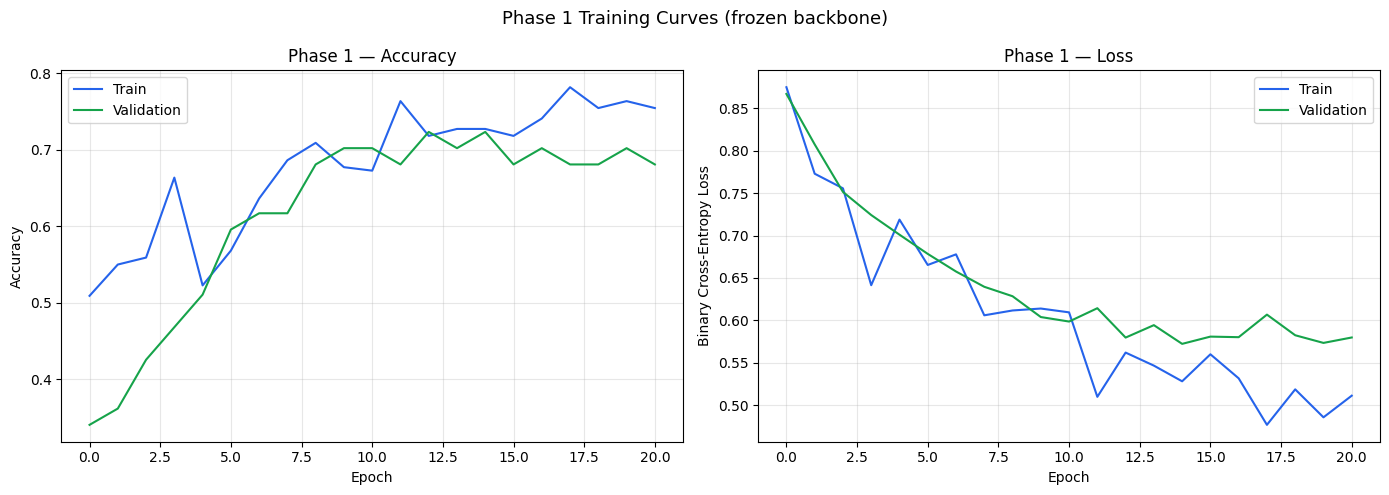

Saved: /content/drive/MyDrive/forged-stamp-recognizer/outputs/figures/phase1_training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase1.history["accuracy"],     label="Train",      color="#2563eb")
axes[0].plot(history_phase1.history["val_accuracy"], label="Validation", color="#16a34a")
axes[0].set_title("Phase 1 — Accuracy", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_phase1.history["loss"],     label="Train",      color="#2563eb")
axes[1].plot(history_phase1.history["val_loss"], label="Validation", color="#16a34a")
axes[1].set_title("Phase 1 — Loss", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Phase 1 Training Curves (frozen backbone)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'phase1_training_curves.png'}")

## Cell 11 — Phase 2: Fine-tuning

We now unfreeze the top 30 layers of the ResNet50 backbone (the last two residual
blocks: `conv5_block1`, `conv5_block2`, `conv5_block3`).

**Why only the top layers?**  
Lower layers detect universal low-level features (edges, textures, curves) that are
equally useful for stamp classification. Upper layers encode higher-level patterns
that are specific to ImageNet categories. We want to re-specialise only the upper
layers for ink texture discrimination.

**Very low learning rate (1e-5):**  
A high LR would catastrophically overwrite the pre-trained weights with noise from
our small dataset. 1e-5 allows gentle, controlled adaptation.

In [ ]:
# Unfreeze top 30 layers of ResNet50
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False  # Keep lower layers frozen

trainable_count = sum(1 for l in base_model.layers if l.trainable)
total_count     = len(base_model.layers)
print(f"ResNet50 layers: {total_count} total, {trainable_count} now trainable (top 30)")
print(f"Total trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

# Recompile with low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10× smaller than Phase 1
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "stamp_resnet50_phase2_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1,
    ),
]

print("\nPhase 2: Fine-tuning top 30 layers (lr=1e-5)...")

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,
)

ResNet50 layers: 175 total, 30 now trainable (top 30)
Total trainable params: 14,712,577

Phase 2: Fine-tuning top 30 layers (lr=1e-5)...
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6996 - auc: 0.7922 - loss: 0.6863 - precision: 0.8430 - recall: 0.4016
Epoch 1: val_loss improved from None to 0.54771, saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_resnet50_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_resnet50_phase2_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7273 - auc: 0.8218 - loss: 0.5972 - precision: 0.8077 - recall: 0.4565 - val_accuracy: 0.7234 - val_auc: 0.8287 - val_loss: 0.5477 - val_precision: 0.8889 - val_recall: 0.4000 - learning_rate: 1.0000e-05
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7836 - auc: 0.8876 - loss: 0.5190 - precision: 0.9214 - recall: 0.5875
Epoch 2: val_loss improved from 0.54771 t

## Cell 12 — Combined training curves (Phase 1 + Phase 2)

The vertical dashed line shows where fine-tuning begins. Typically you expect
to see a small improvement in validation accuracy/loss after fine-tuning starts.

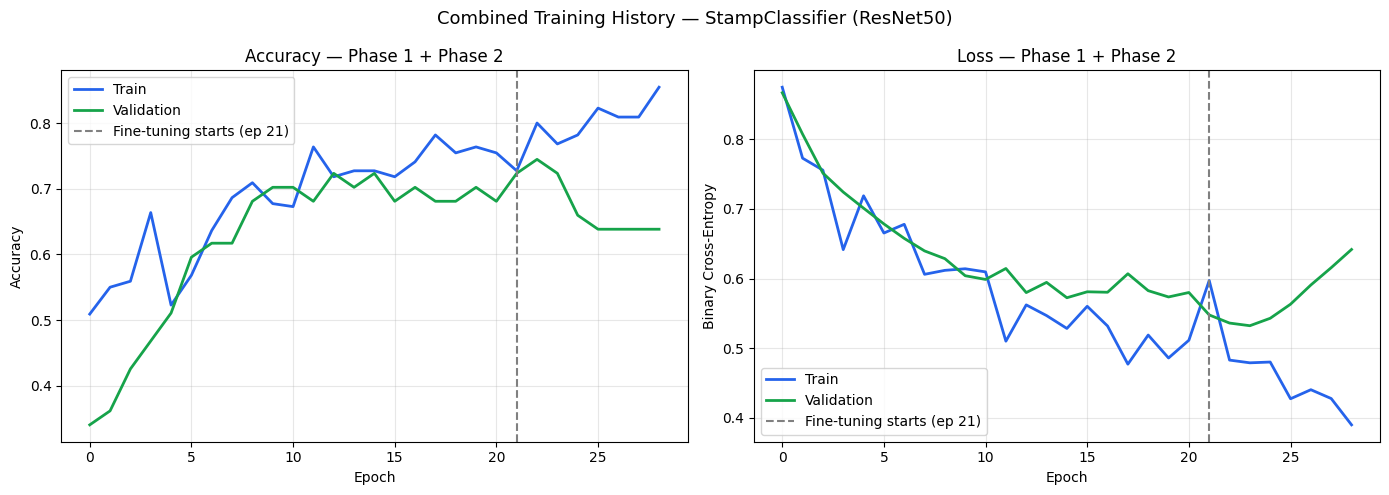

Saved: /content/drive/MyDrive/forged-stamp-recognizer/outputs/figures/combined_training_curves.png


In [ ]:
p1_len = len(history_phase1.history["accuracy"])

acc_combined     = history_phase1.history["accuracy"]     + history_phase2.history["accuracy"]
val_acc_combined = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss_combined    = history_phase1.history["loss"]         + history_phase2.history["loss"]
val_loss_combined= history_phase1.history["val_loss"]     + history_phase2.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_vals, val_vals, title, ylabel in [
    (axes[0], acc_combined, val_acc_combined, "Accuracy — Phase 1 + Phase 2", "Accuracy"),
    (axes[1], loss_combined, val_loss_combined, "Loss — Phase 1 + Phase 2", "Binary Cross-Entropy"),
]:
    ax.plot(train_vals, label="Train",      color="#2563eb", lw=2)
    ax.plot(val_vals,   label="Validation", color="#16a34a", lw=2)
    ax.axvline(p1_len, color="gray", linestyle="--", lw=1.5,
               label=f"Fine-tuning starts (ep {p1_len})")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Combined Training History — StampClassifier (ResNet50)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "combined_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'combined_training_curves.png'}")

## Cell 13 — Evaluate on test set

This is the **final, unbiased evaluation**. The test set was never used during
training or for any hyperparameter decisions, so these numbers are representative
of real-world performance.

For full evaluation charts (ROC, PR, Grad-CAM, inference speed), see **notebook 06**.

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

  TEST SET RESULTS
              precision    recall  f1-score   support

     genuine       0.79      0.96      0.87        28
      forged       0.93      0.65      0.76        20

    accuracy                           0.83        48
   macro avg       0.86      0.81      0.82        48
weighted avg       0.85      0.83      0.83        48



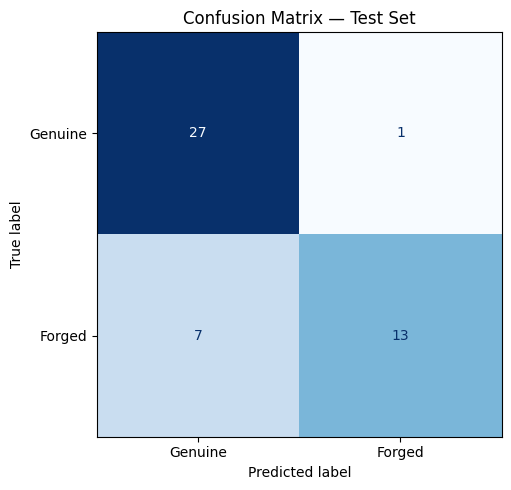

F1-score (forged class): 0.7647


In [ ]:
y_true = test_df["label"].values
y_prob = model.predict(test_ds, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n" + "=" * 50)
print("  TEST SET RESULTS")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=["genuine", "forged"]))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Genuine", "Forged"]).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Test Set", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

f1 = 2*(y_pred[y_true==1].sum()/(y_pred[y_true==1].sum()+((y_pred==1)&(y_true==0)).sum()+1e-8)) * \
     (y_pred[y_true==1].sum()/(y_true.sum()+1e-8)) / \
     ((y_pred[y_true==1].sum()/(y_pred[y_true==1].sum()+((y_pred==1)&(y_true==0)).sum()+1e-8)) + \
      (y_pred[y_true==1].sum()/(y_true.sum()+1e-8)) + 1e-8)

from sklearn.metrics import f1_score as sk_f1
f1 = sk_f1(y_true, y_pred, pos_label=1)
print(f"F1-score (forged class): {f1:.4f}")

## Cell 14 — Save the final model

In [ ]:
final_model_path = MODEL_DIR / "stamp_resnet50_final.keras"
model.save(str(final_model_path))

print(f"Model saved to: {final_model_path.resolve()}")
print()
print("Next step: Run notebook 06 for the full evaluation report (ROC curve,")
print("Precision-Recall curve, Grad-CAM gallery, inference speed analysis).")

Model saved to: /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_resnet50_final.keras

Next step: Run notebook 06 for the full evaluation report (ROC curve,
Precision-Recall curve, Grad-CAM gallery, inference speed analysis).


In [ ]:
# ── Rebuild model with stronger regularisation ────────────────────────────────
base_model2 = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model2.trainable = False

inputs2  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x2       = data_augmentation(inputs2)
x2       = base_model2(x2, training=False)
x2       = layers.GlobalAveragePooling2D()(x2)
x2       = layers.Dropout(0.5)(x2)          # stronger dropout
x2       = layers.Dense(256, activation="relu")(x2)
x2       = layers.BatchNormalization()(x2)   # batch norm helps small datasets
x2       = layers.Dropout(0.4)(x2)
x2       = layers.Dense(64, activation="relu")(x2)
x2       = layers.Dropout(0.3)(x2)
outputs2 = layers.Dense(1, activation="sigmoid")(x2)

model2 = models.Model(inputs2, outputs2, name="StampClassifier_V2")
model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")]
)
print(f"Model V2 built. Parameters: {model2.count_params():,}")

Model V2 built. Parameters: 24,129,793


In [ ]:
# Phase 1 — longer patience this time
callbacks_v2_p1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",          # monitor AUC not loss
        patience=8,                 # longer patience
        restore_best_weights=True,
        mode="max",                 # higher AUC is better
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_DIR + "/stamp_v2_phase1_best.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=4,
        mode="max",
        min_lr=1e-7,
        verbose=1
    ),
]

print("Phase 1 V2: Training...")
history_v2_p1 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_v2_p1,
    class_weight=class_weight_dict
)
print("Phase 1 V2 done.")

Phase 1 V2: Training...
Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6467 - auc: 0.7311 - loss: 0.6656 - precision: 0.5430 - recall: 0.7125
Epoch 1: val_auc improved from None to 0.95833, saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_v2_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_v2_phase1_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 695ms/step - accuracy: 0.6818 - auc: 0.7489 - loss: 0.6247 - precision: 0.6078 - recall: 0.6739 - val_accuracy: 0.7447 - val_auc: 0.9583 - val_loss: 0.4530 - val_precision: 1.0000 - val_recall: 0.4000 - learning_rate: 1.2500e-05
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7618 - auc: 0.8348 - loss: 0.5043 - precision: 0.7061 - recall: 0.7685
Epoch 2: val_auc did not improve from 0.95833
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 392ms/step - accuracy: 0.7591 - auc: 0.8270 - loss: 0.5157 - precision: 0.6970 - recall: 0

In [ ]:
# Phase 2 — unfreeze top 50 layers this time (more fine-tuning)
base_model2.trainable = True
for layer in base_model2.layers[:-50]:
    layer.trainable = False

trainable = sum(1 for l in base_model2.layers if l.trainable)
print(f"Unfroze top {trainable} layers")

model2.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),  # even lower lr
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")]
)

callbacks_v2_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_DIR + "/stamp_v2_phase2_best.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.3,
        patience=4,
        mode="max",
        min_lr=1e-8,
        verbose=1
    ),
]

print("Phase 2 V2: Fine-tuning...")
history_v2_p2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_v2_p2,
    class_weight=class_weight_dict
)
print("Phase 2 V2 done.")

Unfroze top 50 layers
Phase 2 V2: Fine-tuning...
Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.6932 - auc: 0.7392 - loss: 0.7247 - precision: 0.5887 - recall: 0.6792
Epoch 1: val_auc improved from None to 0.95370, saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_v2_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/forged-stamp-recognizer/outputs/models/stamp_v2_phase2_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6409 - auc: 0.6993 - loss: 0.7787 - precision: 0.5684 - recall: 0.5870 - val_accuracy: 0.7447 - val_auc: 0.9537 - val_loss: 0.4546 - val_precision: 1.0000 - val_recall: 0.4000 - learning_rate: 5.0000e-06
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.6660 - auc: 0.7131 - loss: 0.7438 - precision: 0.5999 - recall: 0.6621
Epoch 2: val_auc did not improve from 0.95370
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 376ms/step - accuracy: 0.6818 - auc: 0.7501 - loss: 0.6575 - precis

In [ ]:
# Save V2 model
model2.save(MODEL_DIR + "/stamp_resnet50_v2_final.keras")
print("V2 model saved.")

# Quick evaluation
y_prob2 = model2.predict(test_ds).ravel()
y_pred2 = (y_prob2 >= 0.3).astype(int)

print("\n" + "="*50)
print("  V2 TEST RESULTS")
print("="*50)
print(classification_report(y_true, y_pred2, target_names=["genuine", "forged"]))

# Threshold check
print("\nThreshold optimization V2:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*45)
for thresh in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    preds = (y_prob2 >= thresh).astype(int)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)
    f = f1_score(y_true, preds, zero_division=0)
    print(f"{thresh:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Threshold optimization V2:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*45)
for thresh in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    preds = (y_prob2 >= thresh).astype(int)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)
    f = f1_score(y_true, preds, zero_division=0)
    print(f"{thresh:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

Threshold optimization V2:
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.20      0.655      0.950      0.776
      0.25      0.720      0.900      0.800
      0.30      0.750      0.900      0.818
      0.35      0.810      0.850      0.829
      0.40      0.850      0.850      0.850
      0.50      0.867      0.650      0.743
